# Code

---



In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [12]:
df = pd.read_csv("/content/Renewable_Energy_Usage_Sampled.csv")

df.head(15)

,Household_ID,Region,Country,Energy_Source,Monthly_Usage_kWh,Year,Household_Size,Income_Level,Urban_Rural,Adoption_Year,Subsidy_Received,Cost_Savings_USD
0,H01502,North America,USA,Hydro,1043.49,2024,5,Low,Urban,2012,No,10.46
1,H02587,Australia,Australia,Geothermal,610.01,2024,4,High,Rural,2023,No,43.49
2,H02654,North America,USA,Biomass,1196.75,2024,8,Low,Rural,2017,Yes,93.28
3,H01056,South America,Colombia,Biomass,629.67,2024,7,High,Urban,2023,No,472.85
4,H00706,Africa,Egypt,Hydro,274.46,2022,7,Middle,Rural,2010,No,65.98
5,H00107,South America,Brazil,Biomass,375.99,2022,2,High,Urban,2011,No,20.93
6,H00590,Africa,Ghana,Geothermal,547.50,2020,8,High,Rural,2012,Yes,21.99
7,H02469,Australia,New Zealand,Geothermal,759.23,2024,4,Low,Urban,2020,Yes,127.02
8,H02414,South America,Peru,Biomass,571.70,2021,6,Low,Rural,2021,Yes,199.20
9,H01601,South America,Argentina,Geothermal,851.77,2023,8,High,Urban,2019,Yes,108.09


In [14]:
df.tail(15)

,Household_ID,Region,Country,Energy_Source,Monthly_Usage_kWh,Year,Household_Size,Income_Level,Urban_Rural,Adoption_Year,Subsidy_Received,Cost_Savings_USD
985,H01947,South America,Peru,Geothermal,764.69,2021,8,High,Urban,2010,No,240.57
986,H02776,North America,USA,Solar,1032.40,2023,3,Middle,Rural,2013,Yes,92.13
987,H00193,North America,Mexico,Geothermal,72.69,2022,6,High,Rural,2014,No,472.22
988,H04850,North America,USA,Solar,721.55,2020,7,High,Urban,2010,Yes,163.53
989,H04940,South America,Brazil,Solar,1111.92,2021,7,High,Urban,2020,Yes,111.27
990,H00945,Africa,South Africa,Solar,870.61,2024,7,Low,Urban,2012,Yes,429.35
991,H01269,Asia,India,Wind,978.57,2022,5,High,Urban,2013,No,290.68
992,H04232,Europe,UK,Geothermal,1174.70,2021,6,Low,Rural,2021,Yes,107.58
993,H02308,Asia,Japan,Biomass,1013.88,2021,2,Low,Urban,2021,No,495.07
994,H04425,Asia,Japan,Hydro,272.15,2022,6,High,Rural,2022,Yes,394.18


In [5]:
print("Data Information:")
df.info()

Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Household_ID       1000 non-null   object 
 1   Region             1000 non-null   object 
 2   Country            1000 non-null   object 
 3   Energy_Source      1000 non-null   object 
 4   Monthly_Usage_kWh  1000 non-null   float64
 5   Year               1000 non-null   int64  
 6   Household_Size     1000 non-null   int64  
 7   Income_Level       1000 non-null   object 
 8   Urban_Rural        1000 non-null   object 
 9   Adoption_Year      1000 non-null   int64  
 10  Subsidy_Received   1000 non-null   object 
 11  Cost_Savings_USD   1000 non-null   float64
dtypes: float64(2), int64(3), object(7)
memory usage: 93.9+ KB


In [4]:
print("Data Description:")
df.describe()

Data Description:


,Monthly_Usage_kWh,Year,Household_Size,Adoption_Year,Cost_Savings_USD
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,767.325530,2021.992000,4.480000,2015.992000,248.389850
std,419.649102,1.419137,2.297581,3.973629,143.127301
min,50.740000,2020.000000,1.000000,2010.000000,10.420000
25%,402.730000,2021.000000,2.000000,2013.000000,122.122500
50%,760.190000,2022.000000,5.000000,2016.000000,242.530000
75%,1117.747500,2023.000000,6.000000,2019.000000,372.520000
max,1497.340000,2024.000000,8.000000,2024.000000,499.830000


# Analysis

---
1.This data is about monthly energy usage of all countries between year 2020 and 2024.

2.Many countries uses different energy sources like hydro,geothermal,biomass,wind etc.

3.Minimum monthly usage is 50.740000Kwh and maximum energy usage is 1497.340000Kwh.

4.Government subsidy may influence renewable energy adoption.

5.Urban and Rural households may have different adoption rates.

6.It is generally seen that urban household are saving more as compared to rural household.

7.Generally every country is using at least 500Kwh of monthly energy.

8.Income level may influence renewable energy installation.

9.Energy source,Income level,Urban-Rural,Region are categorial data

10.Different renewable sources produce different levels of savings.

11.Different regions have varying renewable energy usage patterns.

12.Larger families generally consume more electricity.

In [15]:
#Check null values
print(df.isnull().sum())

Household_ID         0
Region               0
Country              0
Energy_Source        0
Monthly_Usage_kWh    0
Year                 0
Household_Size       0
Income_Level         0
Urban_Rural          0
Adoption_Year        0
Subsidy_Received     0
Cost_Savings_USD     0
dtype: int64


In [ ]:
#Handling missing values of numerical data
df['Monthly_Usage_kWh'].fillna(df['Monthly_Usage_kWh'].mean(), inplace=True)

df['Cost_Savings_USD'].fillna(df['Cost_Savings_USD'].mean(), inplace=True)

In [ ]:
#Handling missing values of categorial data
df['Energy_Source'].fillna(df['Energy_Source'].mode()[0], inplace=True)

df['Income_Level'].fillna(df['Income_Level'].mode()[0], inplace=True)

In [18]:
#feature engineering
df['Savings_per_kWh'] = df['Cost_Savings_USD'] / df['Monthly_Usage_kWh']

print(df['Savings_per_kWh'].head())

0    0.010024
1    0.071294
2    0.077944
3    0.750949
4    0.240399
Name: Savings_per_kWh, dtype: float64


In [32]:
categorical_cols = df.select_dtypes(include='object').columns

df = pd.get_dummies(df, columns=categorical_cols)

In [25]:
scaler = StandardScaler()

scale_cols = [
    'Monthly_Usage_kWh',
    'Household_Size',
    'Adoption_Year',
    'Cost_Savings_USD',
    'Savings_per_kWh'
]

df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("\nScaling Completed")


Scaling Completed


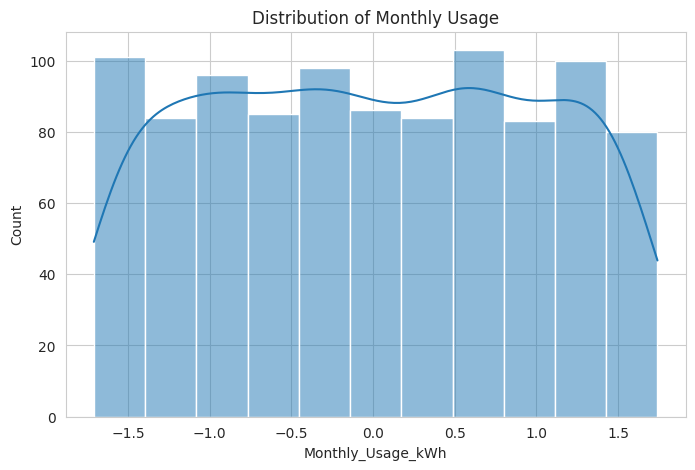

In [29]:
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly_Usage_kWh'], kde=True)
plt.title("Distribution of Monthly Usage")
plt.show()

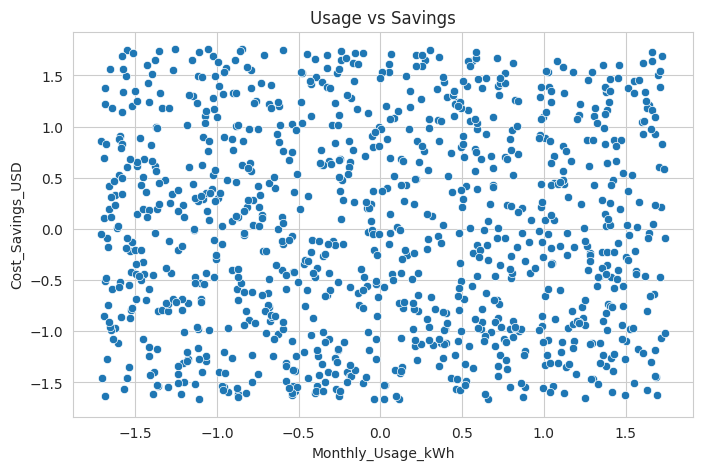

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Monthly_Usage_kWh',
    y='Cost_Savings_USD',
    data=df
)

plt.title("Usage vs Savings")
plt.show()

# Summary

---

1.Household size is expected to have a positive relationship with monthly energy usage.

2.Cost savings generally increase with renewable energy consumption.

3.Subsidies may influence renewable energy adoption rates.

4.Urban and rural households can show different consumption patterns.

5.Feature engineering (Savings_per_kWh) helps measure renewable energy efficiency.

6.Scaling ensures fair comparison among numerical features.

7.Encoding makes categorical data usable for machine learning algorithms.